In [50]:
import pandas as pd

df = pd.read_csv('/content/online_retail_II.csv', encoding='ISO-8859-1')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nDate range check:")
print(df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Rows: 1067371
Columns: 8

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.7

In [51]:
df_clean = df.copy()

# Remove rows with missing Customer ID
print("Missing Customer IDs:", df_clean['Customer ID'].isna().sum())
df_clean = df_clean.dropna(subset=['Customer ID'])

# Convert InvoiceDate to real datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Remove negative/zero quantities (returns and errors)
print("Non-positive quantities:", (df_clean['Quantity'] <= 0).sum())
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove non-positive prices (data errors)
print("Non-positive prices:", (df_clean['Price'] <= 0).sum())
df_clean = df_clean[df_clean['Price'] > 0]

# Calculate revenue per row
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print("\nData after cleaning:")
print("Rows:", len(df_clean))
print("Date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())
print("\nFirst 5 rows:")
print(df_clean[['Invoice', 'InvoiceDate', 'Quantity', 'Price', 'Revenue', 'Customer ID', 'Country']].head())

Missing Customer IDs: 243007
Non-positive quantities: 18744
Non-positive prices: 71

Data after cleaning:
Rows: 805549
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

First 5 rows:
  Invoice         InvoiceDate  Quantity  Price  Revenue  Customer ID  \
0  489434 2009-12-01 07:45:00        12   6.95     83.4      13085.0   
1  489434 2009-12-01 07:45:00        12   6.75     81.0      13085.0   
2  489434 2009-12-01 07:45:00        12   6.75     81.0      13085.0   
3  489434 2009-12-01 07:45:00        48   2.10    100.8      13085.0   
4  489434 2009-12-01 07:45:00        24   1.25     30.0      13085.0   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  


In [52]:
# Group into daily totals
daily_data = df_clean.groupby(df_clean['InvoiceDate'].dt.date).agg({
    'Revenue': 'sum',
    'Invoice': 'nunique'
}).reset_index()

daily_data.columns = ['Date', 'Revenue', 'Orders']
daily_data['Date'] = pd.to_datetime(daily_data['Date'])
daily_data = daily_data.sort_values('Date').reset_index(drop=True)

print("Daily data shape:", daily_data.shape)
print("Date range:", daily_data['Date'].min(), "to", daily_data['Date'].max())

# Check how many calendar days this spans vs how many we actually have data for
calendar_days = (daily_data['Date'].max() - daily_data['Date'].min()).days + 1
print(f"\nCalendar days in range: {calendar_days}")
print(f"Days with actual data: {len(daily_data)}")
print(f"Missing/gap days: {calendar_days - len(daily_data)}")

print("\nFirst 5 days:")
print(daily_data.head())
print("\nSummary statistics:")
print(daily_data.describe())

Daily data shape: (604, 3)
Date range: 2009-12-01 00:00:00 to 2011-12-09 00:00:00

Calendar days in range: 739
Days with actual data: 604
Missing/gap days: 135

First 5 days:
        Date   Revenue  Orders
0 2009-12-01  44048.69      98
1 2009-12-02  52941.99     110
2 2009-12-03  67479.08     122
3 2009-12-04  34064.41      80
4 2009-12-05   9803.05      30

Summary statistics:
                                Date        Revenue      Orders
count                            604     604.000000  604.000000
mean   2010-12-09 10:17:29.006622464   29376.538374   61.206954
min              2009-12-01 00:00:00    3457.110000   11.000000
25%              2010-06-09 18:00:00   18830.260000   44.000000
50%              2010-12-04 00:00:00   25703.780000   58.000000
75%              2011-06-15 06:00:00   35558.427500   73.000000
max              2011-12-09 00:00:00  184367.280000  146.000000
std                              NaN   17051.748185   23.822768


Convert to weekly totals

In [53]:
# Aggregate to weekly (smooths out single-day spikes like that £184,367 outlier day)
weekly_data = daily_data.resample('W', on='Date').agg({
    'Revenue': 'sum',
    'Orders': 'sum'
}).reset_index()

print("Weekly data shape:", weekly_data.shape)
print("\nFirst 5 weeks:")
print(weekly_data.head())
print("\nLast 5 weeks:")
print(weekly_data.tail())
print("\nSummary statistics:")
print(weekly_data.describe())

Weekly data shape: (106, 3)

First 5 weeks:
        Date    Revenue  Orders
0 2009-12-06  232917.94     512
1 2009-12-13  209021.27     494
2 2009-12-20  208936.75     441
3 2009-12-27   35778.20      65
4 2010-01-03       0.00       0

Last 5 weeks:
          Date    Revenue  Orders
101 2011-11-13  264765.98     608
102 2011-11-20  277773.94     669
103 2011-11-27  249532.68     594
104 2011-12-04  251788.22     633
105 2011-12-11  408587.15     484

Summary statistics:
                      Date        Revenue      Orders
count                  106     106.000000  106.000000
mean   2010-12-08 12:00:00  167390.841302  348.764151
min    2009-12-06 00:00:00       0.000000    0.000000
25%    2010-06-07 18:00:00  120951.453250  270.000000
50%    2010-12-08 12:00:00  149776.120000  321.000000
75%    2011-06-10 06:00:00  200564.145000  429.000000
max    2011-12-11 00:00:00  412154.510000  669.000000
std                    NaN   72760.485767  126.848207


Backtest properly (hold out last 10 weeks)

In [54]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

train_size_w = len(weekly_data) - 10
train_weekly = weekly_data.iloc[:train_size_w][['Date', 'Revenue']].copy()
test_weekly = weekly_data.iloc[train_size_w:][['Date', 'Revenue']].copy()

train_weekly.columns = ['ds', 'y']
test_weekly.columns = ['ds', 'y']
test_weekly['ds'] = pd.to_datetime(test_weekly['ds'])

print(f"Training on {len(train_weekly)} weeks, testing on {len(test_weekly)} weeks")

weekly_model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
weekly_model.fit(train_weekly)

future_weekly = weekly_model.make_future_dataframe(periods=10, freq='W')
forecast_weekly = weekly_model.predict(future_weekly)
forecast_weekly['ds'] = pd.to_datetime(forecast_weekly['ds'])

comparison_weekly = test_weekly.merge(
    forecast_weekly[['ds', 'yhat']], on='ds', how='inner'
)
comparison_weekly['yhat'] = comparison_weekly['yhat'].clip(lower=0)

mape_weekly = mean_absolute_percentage_error(comparison_weekly['y'], comparison_weekly['yhat']) * 100

print(f"\n📊 Weekly MAPE: {mape_weekly:.2f}%")
print(f"Matched {len(comparison_weekly)} of {len(test_weekly)} test weeks")
comparison_weekly.columns = ['Date', 'Actual', 'Predicted']
comparison_weekly['Predicted'] = comparison_weekly['Predicted'].round(2)
print(comparison_weekly.to_string(index=False))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Training on 96 weeks, testing on 10 weeks

📊 Weekly MAPE: 13.72%
Matched 10 of 10 test weeks
      Date    Actual  Predicted
2011-10-09 297116.86  264876.91
2011-10-16 204423.28  249013.26
2011-10-23 255461.64  244277.09
2011-10-30 237685.49  249157.27
2011-11-06 260628.77  249529.23
2011-11-13 264765.98  247352.39
2011-11-20 277773.94  263040.66
2011-11-27 249532.68  302461.57
2011-12-04 251788.22  331612.57
2011-12-11 408587.15  301080.14


Generate the real future forecast

In [55]:
# Train on ALL available weekly data (not just the backtest training set)
full_weekly = weekly_data[['Date', 'Revenue']].copy()
full_weekly.columns = ['ds', 'y']

final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
final_model.fit(full_weekly)

future = final_model.make_future_dataframe(periods=12, freq='W')  # forecast 12 weeks ahead
forecast = final_model.predict(future)
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)

# Show just the future predictions
future_only = forecast[forecast['ds'] > full_weekly['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
future_only.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
print(future_only.round(2).to_string(index=False))

future_only.to_csv('weekly_revenue_forecast.csv', index=False)
print("\n✅ Saved: weekly_revenue_forecast.csv")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


      Date  Forecast  Lower_Bound  Upper_Bound
2011-12-18 217841.19    174277.94    261576.13
2011-12-25 102707.40     58528.05    147422.05
2012-01-01  42457.35         0.00     83180.16
2012-01-08  70531.48     24363.69    113526.71
2012-01-15 140660.61     97407.84    185221.30
2012-01-22 177259.51    135631.59    221813.59
2012-01-29 152866.35    106989.05    197242.23
2012-02-05 107807.83     65028.07    151553.65
2012-02-12  96128.33     52325.80    137584.93
2012-02-19 125053.61     79408.98    169820.12
2012-02-26 155803.18    110031.69    202932.66
2012-03-04 156263.87    112239.73    198418.96

✅ Saved: weekly_revenue_forecast.csv


In [56]:
# Check: how many actual days of data feed into that last week?
last_week_days = daily_data[daily_data['Date'] >= '2011-12-05']
print(last_week_days)
print(f"\nDays in final week: {len(last_week_days)} (should be 7 for a complete week)")

# If it's genuinely partial, drop it before training the final model
weekly_data_adjusted = weekly_data[weekly_data['Date'] < '2011-12-11'].copy()
print(f"\nRows before: {len(weekly_data)}, after removing partial week: {len(weekly_data_adjusted)}")

          Date    Revenue  Orders
599 2011-12-05   58202.21     116
600 2011-12-06   46144.04     110
601 2011-12-07   69354.21     104
602 2011-12-08   50519.41     113
603 2011-12-09  184367.28      41

Days in final week: 5 (should be 7 for a complete week)

Rows before: 106, after removing partial week: 105


In [57]:
full_weekly_orders = weekly_data[['Date', 'Orders']].copy()
full_weekly_orders.columns = ['ds', 'y']

orders_model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
orders_model.fit(full_weekly_orders)

future_orders = orders_model.make_future_dataframe(periods=12, freq='W')
forecast_orders = orders_model.predict(future_orders)
forecast_orders['yhat'] = forecast_orders['yhat'].clip(lower=0)
forecast_orders['yhat_lower'] = forecast_orders['yhat_lower'].clip(lower=0)

future_orders_only = forecast_orders[forecast_orders['ds'] > full_weekly_orders['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
future_orders_only.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
print(future_orders_only.round(1).to_string(index=False))

future_orders_only.to_csv('weekly_orders_forecast.csv', index=False)

# Also export the full historical weekly data + backtest results for your dashboard
weekly_data.to_csv('weekly_historical_data.csv', index=False)
comparison_weekly.to_csv('backtest_results.csv', index=False)

print("\n✅ All files saved:")
print("  - weekly_revenue_forecast.csv")
print("  - weekly_orders_forecast.csv")
print("  - weekly_historical_data.csv")
print("  - backtest_results.csv")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


      Date  Forecast  Lower_Bound  Upper_Bound
2011-12-18     345.5        287.3        398.3
2011-12-25     167.6        108.9        225.9
2012-01-01      62.7          9.6        120.5
2012-01-08      76.7         19.6        133.0
2012-01-15     170.6        115.4        228.8
2012-01-22     255.2        194.7        308.5
2012-01-29     272.6        221.2        330.6
2012-02-05     240.1        185.1        298.4
2012-02-12     216.0        158.5        270.6
2012-02-19     231.4        177.2        291.9
2012-02-26     265.7        208.2        320.1
2012-03-04     282.9        230.3        336.5

✅ All files saved:
  - weekly_revenue_forecast.csv
  - weekly_orders_forecast.csv
  - weekly_historical_data.csv
  - backtest_results.csv


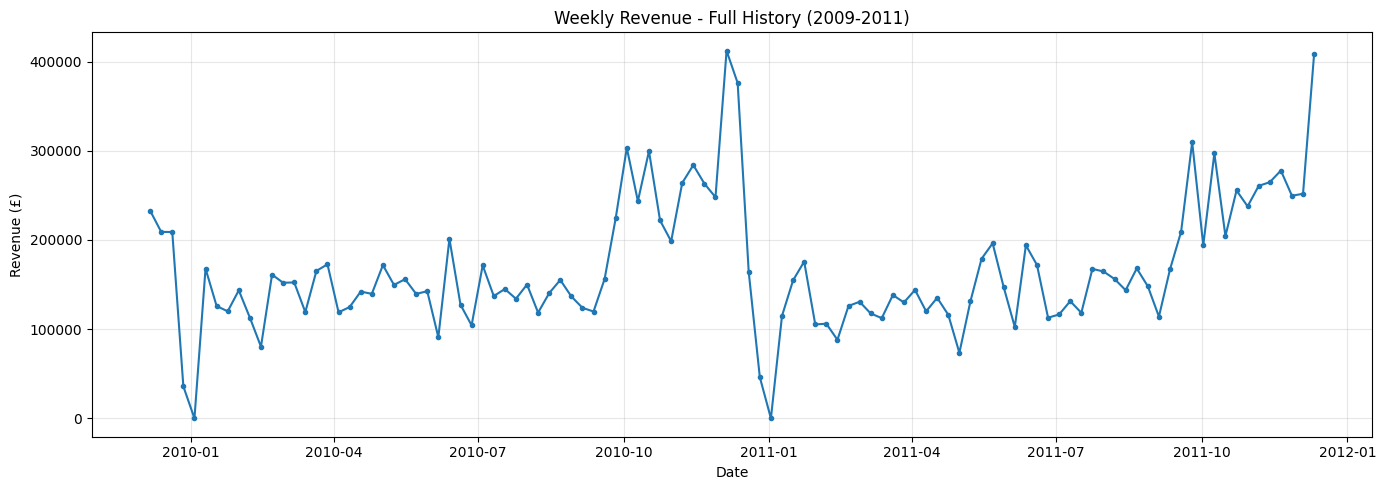

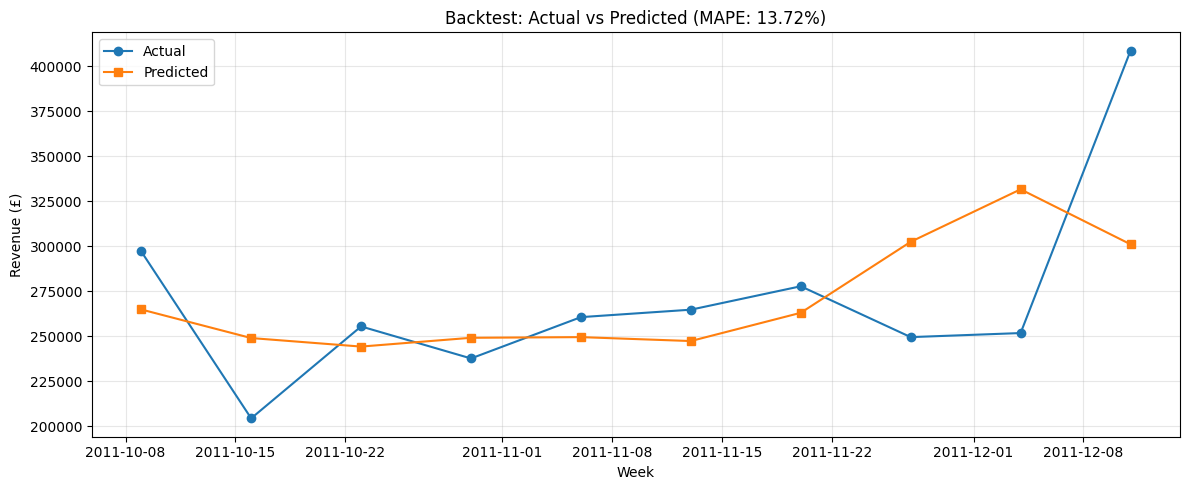

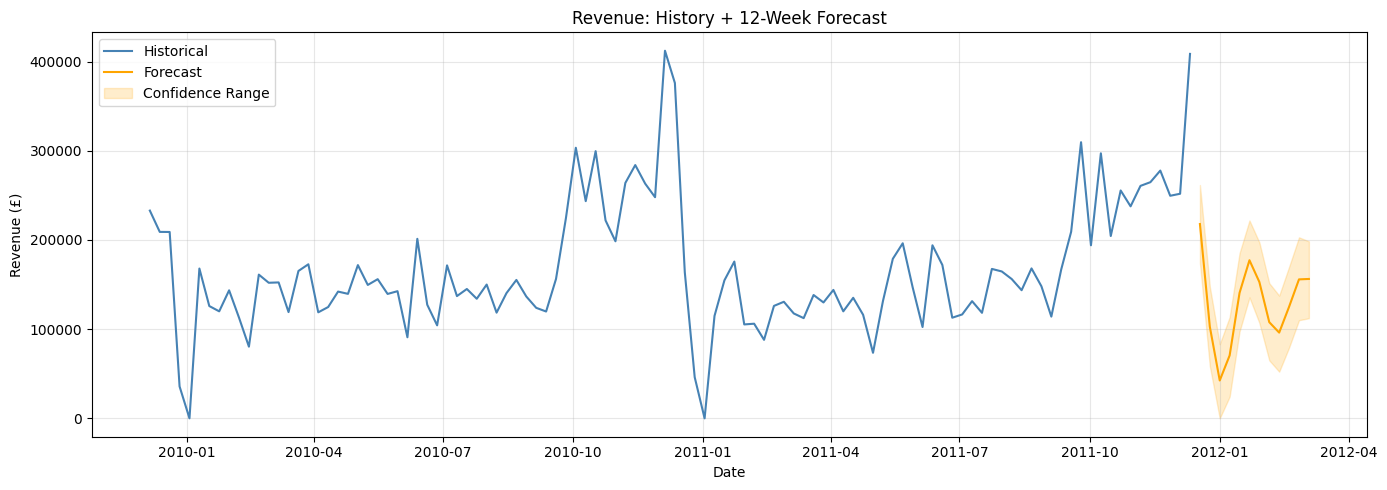

In [61]:
import matplotlib.pyplot as plt

# Chart 1: Full historical weekly revenue trend
plt.figure(figsize=(14, 5))
plt.plot(weekly_data['Date'], weekly_data['Revenue'], marker='o', markersize=3)
plt.title('Weekly Revenue - Full History (2009-2011)')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_historical_revenue.png')
plt.show()

# Chart 2: Backtest - Actual vs Predicted (proves model accuracy visually)
plt.figure(figsize=(12, 5))
plt.plot(comparison_weekly['Date'], comparison_weekly['Actual'], marker='o', label='Actual')
plt.plot(comparison_weekly['Date'], comparison_weekly['Predicted'], marker='s', label='Predicted')
plt.title(f'Backtest: Actual vs Predicted (MAPE: {mape_weekly:.2f}%)')
plt.xlabel('Week')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_backtest.png')
plt.show()

# Chart 3: Full picture - history + future forecast together
plt.figure(figsize=(14, 5))
plt.plot(weekly_data['Date'], weekly_data['Revenue'], label='Historical', color='steelblue')
plt.plot(future_only['Date'], future_only['Forecast'], label='Forecast', color='orange')
plt.fill_between(future_only['Date'], future_only['Lower_Bound'], future_only['Upper_Bound'],
                  color='orange', alpha=0.2, label='Confidence Range')
plt.title('Revenue: History + 12-Week Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_full_forecast.png')
plt.show()